<a href="https://colab.research.google.com/github/jman4162/machine-learning-review/blob/main/Neural_Network_Backpropagation_from_Scratch_with_NumPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Backpropagation from Scratch with NumPy

Name: John Hodge

Date: 06/22/2026

## Introduction

Backpropagation is how a neural network computes the gradient of its loss with respect to every
parameter. A network is a chain of functions; backpropagation applies the chain rule from the loss
backward to each weight, reusing intermediate results so the cost is roughly the same as one forward
pass.

This tutorial builds one small multilayer perceptron (MLP) by hand:

$$X \;\rightarrow\; \text{Linear}_1 \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{Linear}_2 \;\rightarrow\; \text{Softmax + Cross-Entropy} \;\rightarrow\; \text{loss}$$

We implement the forward pass with an explicit cache, derive the backward pass term by term, and
then **check the gradients numerically** against finite differences so the math is verified rather
than asserted. We finish by training the network on a 2D dataset and plotting its decision boundary.

**Why this design for a coding interview.** A single MLP with explicit caches is a better answer than
a general automatic-differentiation engine. It shows the parts an interviewer wants to see: matrix
shapes, the chain rule, a numerically stable softmax, batch averaging, and the parameter update.
A from-scratch autodiff engine spends most of its code on graph bookkeeping, which hides the gradient
math instead of demonstrating it. Build the engine only if asked.

Everything here runs on NumPy and Matplotlib; `scikit-learn` is used only to generate the toy
dataset. The notebook runs top to bottom in Google Colab with no extra installation.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# One generator drives every random draw so results reproduce exactly.
SEED = 0
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("NumPy", np.__version__)

NumPy 1.26.4


## 1. The chain rule, end to end

The forward pass turns inputs into a loss:

$$z_1 = X W_1 + b_1, \qquad h_1 = \mathrm{ReLU}(z_1), \qquad \text{logits} = h_1 W_2 + b_2,
\qquad \mathcal{L} = \text{cross\_entropy}(\mathrm{softmax}(\text{logits}), y).$$

The backward pass wants $\partial \mathcal{L}/\partial W_1$, $\partial \mathcal{L}/\partial b_1$,
$\partial \mathcal{L}/\partial W_2$, $\partial \mathcal{L}/\partial b_2$. Each gradient is a product of
local derivatives along the chain. We compute them right to left, reusing the activation we already
have at each step. The figure below names the tensors that flow forward (top) and the gradients that
flow back (bottom).

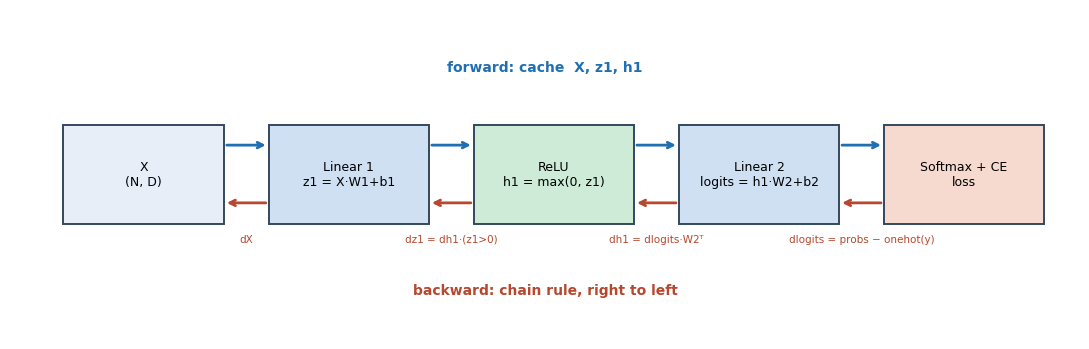

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.set_xlim(0, 12); ax.set_ylim(0, 4); ax.axis("off")

nodes = [
    (0.6,  "X\n(N, D)",            "#e8eef7"),
    (2.9,  "Linear 1\nz1 = X·W1+b1", "#cfe0f3"),
    (5.2,  "ReLU\nh1 = max(0, z1)",  "#cdebd6"),
    (7.5,  "Linear 2\nlogits = h1·W2+b2", "#cfe0f3"),
    (9.8,  "Softmax + CE\nloss",     "#f6d9cf"),
]
w = 1.8
for x, label, color in nodes:
    ax.add_patch(plt.Rectangle((x, 1.4), w, 1.2, facecolor=color,
                               edgecolor="#33485f", linewidth=1.4))
    ax.text(x + w / 2, 2.0, label, ha="center", va="center", fontsize=9)

# forward arrows (top)
for i in range(len(nodes) - 1):
    x0 = nodes[i][0] + w; x1 = nodes[i + 1][0]
    ax.annotate("", xy=(x1, 2.35), xytext=(x0, 2.35),
                arrowprops=dict(arrowstyle="->", color="#1f6fb2", lw=2))
ax.text(6.0, 3.25, "forward: cache  X, z1, h1", ha="center",
        color="#1f6fb2", fontsize=10, weight="bold")

# backward arrows (bottom)
grad_labels = ["dX", "dz1 = dh1·(z1>0)", "dh1 = dlogits·W2ᵀ", "dlogits = probs − onehot(y)"]
for i in range(len(nodes) - 1):
    x0 = nodes[i + 1][0]; x1 = nodes[i][0] + w
    ax.annotate("", xy=(x1, 1.65), xytext=(x0, 1.65),
                arrowprops=dict(arrowstyle="->", color="#b5482e", lw=2))
    ax.text((x0 + x1) / 2, 1.18, grad_labels[i], ha="center",
            color="#b5482e", fontsize=7.5)
ax.text(6.0, 0.55, "backward: chain rule, right to left", ha="center",
        color="#b5482e", fontsize=10, weight="bold")
plt.tight_layout(); plt.show()

## 2. Forward pass and shapes

Shape discipline catches most backprop bugs before they happen. For a batch of $N$ examples with $D$
features, a hidden width $H$, and $C$ classes:

| tensor | shape | meaning |
|---|---|---|
| `X` | $(N, D)$ | input batch |
| `W1`, `b1` | $(D, H)$, $(1, H)$ | first affine layer |
| `z1`, `h1` | $(N, H)$ | pre- and post-ReLU hidden activations |
| `W2`, `b2` | $(H, C)$, $(1, C)$ | second affine layer |
| `logits` | $(N, C)$ | raw class scores (not probabilities) |

A gradient always has the same shape as the tensor it differentiates, so `dW1` is $(D, H)$, `dlogits`
is $(N, C)$, and so on. Checking that at every step is the fastest way to catch a transpose error.

### ReLU and its derivative

$\mathrm{ReLU}(z) = \max(0, z)$ keeps positive values and zeros out the rest. Its derivative is 1 where
the input was positive and 0 elsewhere, so on the backward pass it acts as a gate: gradient flows
through units that were active in the forward pass and is blocked everywhere else.

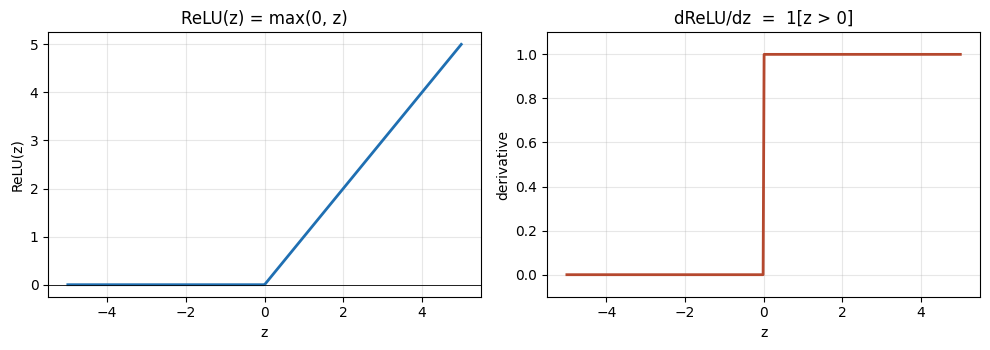

In [3]:
z = np.linspace(-5, 5, 400)
relu = np.maximum(0, z)
relu_grad = (z > 0).astype(float)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.plot(z, relu, color="#1f6fb2", lw=2); a1.set_title("ReLU(z) = max(0, z)")
a1.set_xlabel("z"); a1.set_ylabel("ReLU(z)"); a1.axhline(0, color="k", lw=0.6)
a2.plot(z, relu_grad, color="#b5482e", lw=2); a2.set_title("dReLU/dz  =  1[z > 0]")
a2.set_xlabel("z"); a2.set_ylabel("derivative"); a2.set_ylim(-0.1, 1.1)
plt.tight_layout(); plt.show()

### Softmax: scores to probabilities

Softmax turns a row of logits into a probability distribution over classes:

$$\mathrm{softmax}(\ell)_i = \frac{e^{\ell_i}}{\sum_j e^{\ell_j}}.$$

Subtracting the row maximum before exponentiating leaves the result unchanged (the factor cancels in
numerator and denominator) but prevents overflow when logits are large:

$$\mathrm{softmax}(\ell)_i = \frac{e^{\ell_i - \max_k \ell_k}}{\sum_j e^{\ell_j - \max_k \ell_k}}.$$

logits: [ 2.1 -0.4  0.8]
probs : [0.738 0.061 0.201]  sum = 1.0


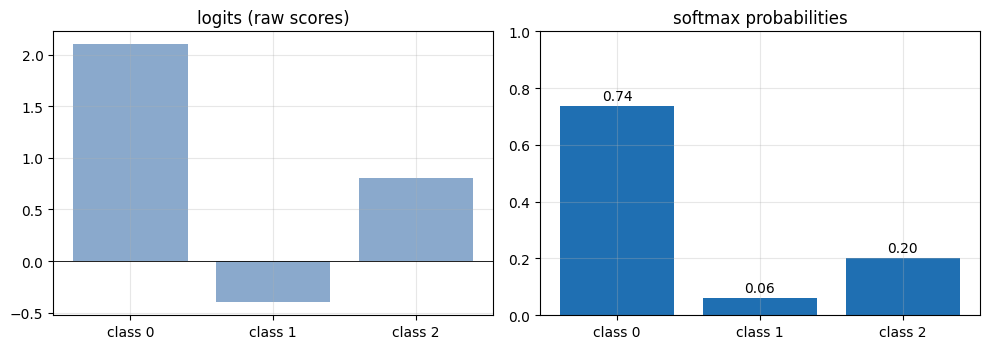

In [4]:
logits_ex = np.array([2.1, -0.4, 0.8])
shifted = logits_ex - logits_ex.max()
probs_ex = np.exp(shifted) / np.exp(shifted).sum()
print("logits:", logits_ex)
print("probs :", np.round(probs_ex, 3), " sum =", probs_ex.sum())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
cls = ["class 0", "class 1", "class 2"]
a1.bar(cls, logits_ex, color="#8aa9cc"); a1.set_title("logits (raw scores)")
a1.axhline(0, color="k", lw=0.6)
a2.bar(cls, probs_ex, color="#1f6fb2"); a2.set_title("softmax probabilities")
a2.set_ylim(0, 1)
for i, p in enumerate(probs_ex):
    a2.text(i, p + 0.02, f"{p:.2f}", ha="center")
plt.tight_layout(); plt.show()

### Cross-entropy loss

For one example, cross-entropy is the negative log probability the model assigned to the correct
class:

$$\mathcal{L} = -\log p_{\text{correct}}.$$

A confident correct prediction ($p \approx 1$) costs almost nothing; a confident wrong one ($p \to 0$)
costs a lot. For a batch we average over the $N$ examples.

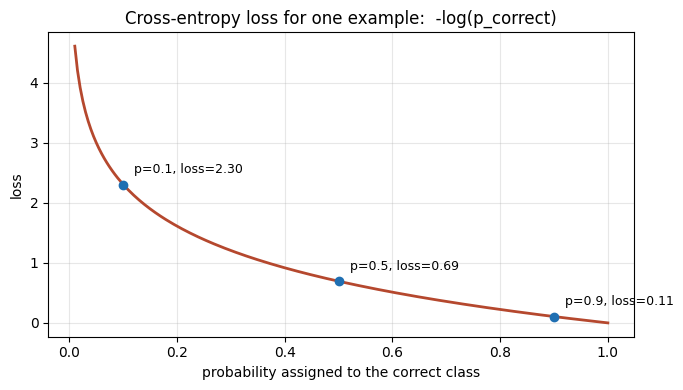

In [5]:
p = np.linspace(0.01, 1.0, 200)
plt.figure(figsize=(7, 4))
plt.plot(p, -np.log(p), color="#b5482e", lw=2)
for q in (0.9, 0.5, 0.1):
    plt.scatter([q], [-np.log(q)], color="#1f6fb2", zorder=5)
    plt.annotate(f"p={q}, loss={-np.log(q):.2f}", (q, -np.log(q)),
                 textcoords="offset points", xytext=(8, 8), fontsize=9)
plt.title("Cross-entropy loss for one example:  -log(p_correct)")
plt.xlabel("probability assigned to the correct class")
plt.ylabel("loss"); plt.tight_layout(); plt.show()

## 3. The key simplification

Softmax and cross-entropy compose into a gradient with a simple closed form. With respect to the
logits,

$$\frac{\partial \mathcal{L}}{\partial \text{logits}} = \text{probs} - \text{onehot}(y),$$

averaged over the batch. In code:

```python
dlogits = probs.copy()
dlogits[np.arange(N), y] -= 1
dlogits /= N
```

Read it as a correction signal: classes the model scored too high get pushed down (positive
gradient), and the true class, scored too low, gets pushed up (negative gradient). The appendix
derives this identity.

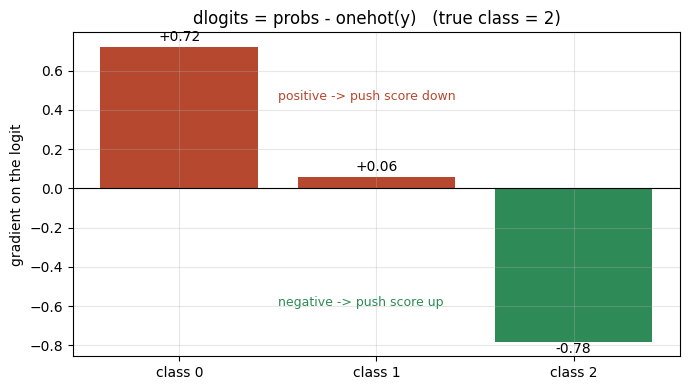

In [6]:
probs_one = np.array([0.72, 0.06, 0.22])   # model output for one example
true_class = 2
onehot = np.zeros(3); onehot[true_class] = 1
dlogits_one = probs_one - onehot

colors = ["#b5482e" if g > 0 else "#2e8b57" for g in dlogits_one]
plt.figure(figsize=(7, 4))
bars = plt.bar(["class 0", "class 1", "class 2"], dlogits_one, color=colors)
plt.axhline(0, color="k", lw=0.8)
plt.title("dlogits = probs - onehot(y)   (true class = 2)")
plt.ylabel("gradient on the logit")
for i, g in enumerate(dlogits_one):
    plt.text(i, g + (0.03 if g >= 0 else -0.06), f"{g:+.2f}", ha="center")
plt.text(0.5, 0.45, "positive -> push score down", color="#b5482e", fontsize=9)
plt.text(0.5, -0.6, "negative -> push score up", color="#2e8b57", fontsize=9)
plt.tight_layout(); plt.show()

## 4. Two rules cover the rest

Once `dlogits` is in hand, the rest of the backward pass is two patterns applied twice.

**Affine layer.** For $Y = XW + b$ with an upstream gradient $dY$:

$$dW = X^\top\, dY, \qquad db = \textstyle\sum_{\text{batch}} dY, \qquad dX = dY\, W^\top.$$

The shapes force the transposes: $dW$ must match $W$, and $dX$ must match $X$. Use
`np.sum(dY, axis=0, keepdims=True)` for `db` so it stays shape $(1, \cdot)$ and broadcasts back
correctly.

**ReLU layer.** Multiply the upstream gradient by the activation mask: `dZ = dH * (Z > 0)`.

**Why divide by the batch size.** The loss is the mean over $N$ examples, so its gradient is also a
mean. We fold the $1/N$ into `dlogits` once; it then propagates through every later gradient. Without
it, gradient magnitude would scale with batch size and changing the batch size would silently change
the effective learning rate.

## 5. Implementation

The functions below are the whole network: initialize, forward (returning a cache), loss, backward,
update, and a single training step.

In [7]:
def init_params(input_dim, hidden_dim, output_dim, seed=0):
    rng = np.random.default_rng(seed)

    # He initialization works well with ReLU.
    params = {
        "W1": rng.standard_normal((input_dim, hidden_dim)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, hidden_dim)),
        "W2": rng.standard_normal((hidden_dim, output_dim)) * np.sqrt(2.0 / hidden_dim),
        "b2": np.zeros((1, output_dim)),
    }
    return params

In [8]:
def forward(X, params):
    """
    X: (N, D); W1: (D, H); b1: (1, H); W2: (H, C); b2: (1, C)

    Returns:
        logits: (N, C)
        cache: values needed for the backward pass
    """
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    z1 = X @ W1 + b1          # (N, H)
    h1 = np.maximum(0, z1)    # ReLU
    logits = h1 @ W2 + b2     # (N, C)

    cache = {"X": X, "z1": z1, "h1": h1, "logits": logits}
    return logits, cache

In [9]:
def softmax_cross_entropy_loss(logits, y):
    """
    logits: (N, C); y: integer class labels, shape (N,)

    Returns:
        loss: scalar
        probs: (N, C)
    """
    N = logits.shape[0]

    # Numerically stable softmax.
    shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted_logits)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

    # Cross-entropy loss.
    correct_log_probs = -np.log(probs[np.arange(N), y] + 1e-12)
    loss = np.mean(correct_log_probs)
    return loss, probs

In [10]:
def backward(params, cache, probs, y):
    """
    Computes gradients for W1, b1, W2, b2 using the identity
        dL/dlogits = probs - onehot(y)
    for softmax + cross-entropy.
    """
    W2 = params["W2"]
    X = cache["X"]            # (N, D)
    z1 = cache["z1"]          # (N, H)
    h1 = cache["h1"]          # (N, H)
    N = X.shape[0]

    # Gradient of the loss with respect to logits.
    dlogits = probs.copy()                        # (N, C)
    dlogits[np.arange(N), y] -= 1
    dlogits /= N                                  # loss is averaged over the batch

    # Second linear layer: logits = h1 @ W2 + b2
    dW2 = h1.T @ dlogits                           # (H, C)
    db2 = np.sum(dlogits, axis=0, keepdims=True)   # (1, C)

    # Backprop into the hidden layer.
    dh1 = dlogits @ W2.T                            # (N, H)

    # ReLU backward.
    dz1 = dh1 * (z1 > 0)                            # (N, H)

    # First linear layer: z1 = X @ W1 + b1
    dW1 = X.T @ dz1                                 # (D, H)
    db1 = np.sum(dz1, axis=0, keepdims=True)        # (1, H)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

In [11]:
def update_params(params, grads, learning_rate):
    for key in params:
        params[key] -= learning_rate * grads[key]


def train_step(X, y, params, learning_rate=1e-2):
    logits, cache = forward(X, params)
    loss, probs = softmax_cross_entropy_loss(logits, y)
    grads = backward(params, cache, probs, y)
    update_params(params, grads, learning_rate)
    return loss, grads

A quick smoke test on random data confirms the forward pass runs and every gradient matches the
shape of its parameter. The shape assertions are the kind of cheap check worth writing during an
interview.

In [12]:
N, D, H, C = 8, 5, 10, 3
rng = np.random.default_rng(42)
X_toy = rng.standard_normal((N, D))
y_toy = rng.integers(0, C, size=N)

params = init_params(D, H, C, seed=SEED)
logits, cache = forward(X_toy, params)
loss, probs = softmax_cross_entropy_loss(logits, y_toy)
grads = backward(params, cache, probs, y_toy)

for key in params:
    assert grads[key].shape == params[key].shape, key
print(f"forward + backward OK   loss = {loss:.4f}")
print("all gradient shapes match their parameters")

forward + backward OK   loss = 0.9151
all gradient shapes match their parameters


## 6. Accuracy check: analytical vs. numerical gradients

An analytical gradient is only correct if it matches the slope of the loss surface. The standard test
is a central finite difference: nudge one parameter by $\pm\varepsilon$, measure the loss change, and
compare to the analytical value:

$$\frac{\partial \mathcal{L}}{\partial \theta} \approx \frac{\mathcal{L}(\theta + \varepsilon) - \mathcal{L}(\theta - \varepsilon)}{2\varepsilon}.$$

In float64 with $\varepsilon = 10^{-5}$, a correct implementation gives a relative error near $10^{-7}$
or smaller. We report the worst element per parameter and stop if any exceeds $10^{-6}$.

In [13]:
def loss_only(params, X, y):
    logits, _ = forward(X, params)
    loss, _ = softmax_cross_entropy_loss(logits, y)
    return loss


def numerical_grads(params, X, y, eps=1e-5):
    num = {}
    for key in params:
        g = np.zeros_like(params[key])
        it = np.nditer(params[key], flags=["multi_index"])
        while not it.finished:
            idx = it.multi_index
            original = params[key][idx]
            params[key][idx] = original + eps
            loss_plus = loss_only(params, X, y)
            params[key][idx] = original - eps
            loss_minus = loss_only(params, X, y)
            params[key][idx] = original          # restore
            g[idx] = (loss_plus - loss_minus) / (2 * eps)
            it.iternext()
        num[key] = g
    return num


# Fresh parameters and data, all float64.
params = init_params(D, H, C, seed=1)
logits, cache = forward(X_toy, params)
loss, probs = softmax_cross_entropy_loss(logits, y_toy)
analytic = backward(params, cache, probs, y_toy)
numeric = numerical_grads(params, X_toy, y_toy)

rel_errors = {}
for key in params:
    a, n = analytic[key], numeric[key]
    rel = np.abs(a - n) / np.maximum(1e-8, np.abs(a) + np.abs(n))
    rel_errors[key] = rel.max()
    print(f"{key}: max relative error = {rel.max():.2e}")

worst = max(rel_errors.values())
assert worst < 1e-6, f"gradient check FAILED: worst relative error {worst:.2e}"
print(f"\ngradient check PASSED (worst relative error = {worst:.2e})")

W1: max relative error = 2.07e-09
b1: max relative error = 4.12e-10
W2: max relative error = 1.69e-10
b2: max relative error = 4.09e-10

gradient check PASSED (worst relative error = 2.07e-09)


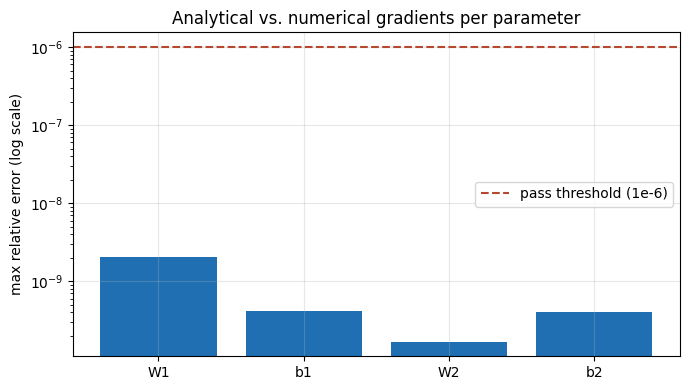

In [14]:
keys = list(rel_errors.keys())
vals = [rel_errors[k] for k in keys]
plt.figure(figsize=(7, 4))
plt.bar(keys, vals, color="#1f6fb2")
plt.axhline(1e-6, color="#b5482e", ls="--", lw=1.5, label="pass threshold (1e-6)")
plt.yscale("log"); plt.ylabel("max relative error (log scale)")
plt.title("Analytical vs. numerical gradients per parameter")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Training on a 2D dataset

`make_moons` gives two interleaving half-circles that no straight line separates, so a hidden layer
with ReLU is needed. We standardize the inputs, then run full-batch gradient descent and record the
loss at each step.

In [15]:
from sklearn.datasets import make_moons

X_data, y_data = make_moons(n_samples=1000, noise=0.20, random_state=0)
X_data = (X_data - X_data.mean(axis=0)) / X_data.std(axis=0)   # standardize
print("X:", X_data.shape, " y:", y_data.shape, " classes:", np.unique(y_data))

params = init_params(input_dim=2, hidden_dim=64, output_dim=2, seed=1)
losses = []
for step in range(2000):
    loss, _ = train_step(X_data, y_data, params, learning_rate=0.5)
    losses.append(loss)
    if step % 400 == 0:
        print(f"step {step:4d}   loss = {loss:.4f}")

logits, _ = forward(X_data, params)
pred = logits.argmax(axis=1)
accuracy = (pred == y_data).mean()
print(f"\nfinal loss = {losses[-1]:.4f}   training accuracy = {accuracy:.3f}")

X: (1000, 2)  y: (1000,)  classes: [0 1]
step    0   loss = 1.3871
step  400   loss = 0.0870


step  800   loss = 0.0787
step 1200   loss = 0.0757


step 1600   loss = 0.0739

final loss = 0.0727   training accuracy = 0.971


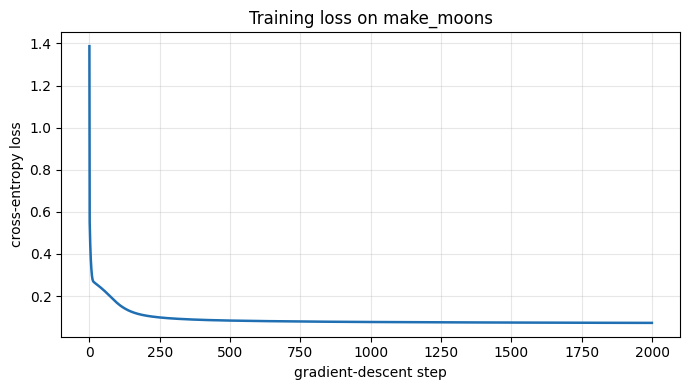

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(losses, color="#1f6fb2", lw=1.8)
plt.xlabel("gradient-descent step"); plt.ylabel("cross-entropy loss")
plt.title("Training loss on make_moons"); plt.tight_layout(); plt.show()

The network learns a curved decision boundary. We evaluate it on a grid covering the input plane
and shade the two predicted regions, then overlay the data.

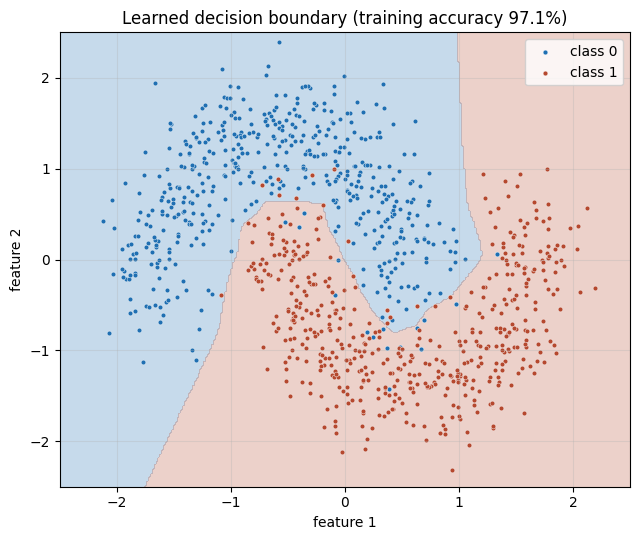

In [17]:
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300), np.linspace(-2.5, 2.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_logits, _ = forward(grid, params)
zz = grid_logits.argmax(axis=1).reshape(xx.shape)

plt.figure(figsize=(6.5, 5.5))
plt.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5],
             colors=["#1f6fb2", "#b5482e"])
plt.scatter(X_data[y_data == 0, 0], X_data[y_data == 0, 1], s=12,
            color="#1f6fb2", edgecolor="white", linewidth=0.3, label="class 0")
plt.scatter(X_data[y_data == 1, 0], X_data[y_data == 1, 1], s=12,
            color="#b5482e", edgecolor="white", linewidth=0.3, label="class 1")
plt.title(f"Learned decision boundary (training accuracy {accuracy:.1%})")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.legend(loc="upper right"); plt.tight_layout(); plt.show()

## 8. Conclusion

The whole backward pass for this network is three reusable pieces:

```python
# softmax + cross-entropy
dlogits = probs.copy()
dlogits[np.arange(N), y] -= 1
dlogits /= N

# affine layer  Y = X @ W + b
dW = X.T @ dY
db = np.sum(dY, axis=0, keepdims=True)
dX = dY @ W.T

# ReLU
dZ = dH * (Z > 0)
```

Memorize the local derivatives and the shape rules, not whole networks. With these you can assemble
the backward pass for a deeper MLP, and the same chain-rule reasoning extends to convolutional and
recurrent layers by swapping in their local gradients.

**What to say out loud in an interview.** Cache the activations the backward pass needs. For softmax
plus cross-entropy the gradient on the logits is `probs - onehot(y)` divided by the batch size.
Backpropagate through the second affine layer, through ReLU with its activation mask, and through the
first affine layer, using `dW = X.T @ dY`, `db = sum(dY)`, `dX = dY @ W.T` each time.

**Common mistakes to avoid.**

- Forgetting to divide by the batch size, which couples the learning rate to the batch size.
- An unstable softmax that overflows; subtract the row max first.
- Mixed-up transposes; let the required output shape pick the transpose.
- Summing biases without `keepdims=True`, which breaks broadcasting on the next step.

The numerical gradient check above is the habit that catches all of these: if analytical and numerical
gradients disagree, the derivation is wrong somewhere.

## Appendix

### Deriving `dlogits = probs - onehot(y)`

For one example with logits $\ell$, softmax produces $p_i = e^{\ell_i} / \sum_j e^{\ell_j}$, and the
cross-entropy loss for true class $t$ is $\mathcal{L} = -\log p_t$. Differentiate with respect to a
logit $\ell_k$. The softmax Jacobian is

$$\frac{\partial p_t}{\partial \ell_k} = p_t(\delta_{tk} - p_k),$$

where $\delta_{tk}$ is 1 when $k = t$ and 0 otherwise. Then

$$\frac{\partial \mathcal{L}}{\partial \ell_k}
= -\frac{1}{p_t}\frac{\partial p_t}{\partial \ell_k}
= -(\delta_{tk} - p_k)
= p_k - \delta_{tk}.$$

Stacked over classes, $\partial \mathcal{L}/\partial \ell = p - \text{onehot}(t)$. Averaging over the
batch adds the $1/N$ factor, which is the `dlogits /= N` line.

### A note on `dX`

The affine rule also gives `dX = dY @ W.T`, the gradient with respect to a layer's input. We do not
use it for the first layer here because `X` is data, not a learnable parameter. In a deeper network it
is exactly what carries the gradient to the previous layer, so it is the term that makes
backpropagation compose.